In [3]:
from google.colab import drive
from google.colab import drive
import gzip
import random
import networkx as nx
from collections import deque
import matplotlib.pyplot as plt

drive.mount('/content/drive')

%cd /content/drive/MyDrive/Colab Notebooks/AM

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Colab Notebooks/AM


In [4]:
adj = {}

with gzip.open('web-Google.txt.gz', 'rt') as f:
  for line in f:
    if line.startswith('#'):
      continue
    u, v = map(int, line.split())
    adj.setdefault(u, []).append(v)
    adj.setdefault(v, []) # ensure node exists

start = random.choice(list(adj.keys()))
visited = set([start])
queue = deque([start])

while queue and len(visited) < 300:
  node = queue.popleft()
  for neighbor in adj.get(node, []):
    if neighbor not in visited:
      visited.add(neighbor)
      queue.append(neighbor)
    if len(visited) >= 300:
      break

# keep edges inside sampled nodes
sample_edges = [(u, v) for u in visited for v in adj.get(u, []) if v in visited]

In [5]:
G = nx.DiGraph()
G.add_nodes_from(visited)
G.add_edges_from(sample_edges)

print(f"Nodes: {nx.number_of_nodes(G)}, Vertices: {nx.number_of_edges(G)}")

Nodes: 300, Vertices: 1605


In [22]:
in_degrees = dict(G.in_degree())
out_degrees = dict(G.out_degree())
normalized_degrees = dict()

print("Some nodes in-degree, out-degree, and normalized degree:")
for node in list(G.nodes())[:10]:
  in_degree = in_degrees[node]
  out_degree = out_degrees[node]
  normalized_in = in_degree / nx.number_of_nodes(G)
  normalized_out = out_degree / nx.number_of_nodes(G)
  normalized_degrees[node] = (normalized_in, normalized_out)

  print(f"Node {node}: in-degree={in_degrees[node]}, out-degree={out_degrees[node]}, normalized degrees (in, out)={normalized_degrees[node]}")

avg_in = sum(in_degrees.values()) / len(in_degrees)
avg_out = sum(out_degrees.values()) / len(out_degrees)

print(f"\nAverage in-degree: {avg_in:.2f}, Average out-degree: {avg_out:.2f}")

Some nodes in-degree, out-degree, and normalized degree:
Node 174592: in-degree=2, out-degree=2, normalized degrees (in, out)=(0.006666666666666667, 0.006666666666666667)
Node 733696: in-degree=20, out-degree=0, normalized degrees (in, out)=(0.06666666666666667, 0.0)
Node 827396: in-degree=1, out-degree=0, normalized degrees (in, out)=(0.0033333333333333335, 0.0)
Node 173572: in-degree=4, out-degree=1, normalized degrees (in, out)=(0.013333333333333334, 0.0033333333333333335)
Node 250886: in-degree=1, out-degree=4, normalized degrees (in, out)=(0.0033333333333333335, 0.013333333333333334)
Node 60428: in-degree=1, out-degree=1, normalized degrees (in, out)=(0.0033333333333333335, 0.0033333333333333335)
Node 396300: in-degree=1, out-degree=11, normalized degrees (in, out)=(0.0033333333333333335, 0.03666666666666667)
Node 183310: in-degree=1, out-degree=9, normalized degrees (in, out)=(0.0033333333333333335, 0.03)
Node 542734: in-degree=1, out-degree=0, normalized degrees (in, out)=(0.003

In [23]:
eigenvector_centrality = nx.eigenvector_centrality(G)

print("Eigenvector Centrality for some nodes:")
for node in list(G.nodes())[:10]:
  print(f"Node {node}: {eigenvector_centrality[node]:.4f}")

Eigenvector Centrality for some nodes:
Node 174592: 0.0000
Node 733696: 0.2017
Node 827396: 0.0000
Node 173572: 0.0000
Node 250886: 0.0000
Node 60428: 0.0000
Node 396300: 0.0000
Node 183310: 0.0000
Node 542734: 0.0000
Node 911376: 0.0000


Although not necessarily representant of all the nodes in the sample, these 10 random contain only 1 well connected (or connected at all) node (to other nodes with a "high score").

In [24]:
pagerank_centrality = nx.pagerank(G)

print("Pagerank Centrality for some nodes:")
for node in list(G.nodes())[:10]:
  print(f"Node {node}: {pagerank_centrality[node]:.4f}")

Pagerank Centrality for some nodes:
Node 174592: 0.0030
Node 733696: 0.0041
Node 827396: 0.0012
Node 173572: 0.0068
Node 250886: 0.0027
Node 60428: 0.0010
Node 396300: 0.0010
Node 183310: 0.0018
Node 542734: 0.0010
Node 911376: 0.0021


It usually makes sense for the Pagerank centrality to be overall higher than the Eigenvector centrality.

In [26]:
density = nx.density(G)
print(f"Density: {density:.4f}")

avg_clustering = nx.average_clustering(G)
print(f"Average Clustering: {avg_clustering:.4f}")

transitivity = nx.transitivity(G)
print(f"Transitivity: {transitivity}")

Density: 0.0179
Average Clustering: 0.4267
Transitivity: 0.6178488641631896


The above metrics indicate relatively low global density and connectivity of the sample subgraph, but a large number of clusters and "closed" connections.

In [82]:
weak_cc = list(nx.weakly_connected_components(G))
print(f"Number of weakly connected components: {len(weak_cc)}")
largest_weak = max(weak_cc, key=len)
print(f"Largest weakly connected component size: {len(largest_weak)}")

strong_cc = list(nx.strongly_connected_components(G))
print(f"Number of strongly connected components: {len(strong_cc)}")
largest_strong = max(strong_cc, key=len)
print(f"Largest strongly connected component size: {len(largest_strong)}")

H = G.subgraph(largest_strong).copy()

nodes = list(H.nodes())
u, v = random.sample(nodes, 2)

shortest_path = nx.shortest_path(H, source=u, target=v)
print(f"Shortest path from {u} to {v}: {shortest_path}")

print(f"Number of edges in this path: {len(shortest_path)-1}")

Number of weakly connected components: 1
Largest weakly connected component size: 300
Number of strongly connected components: 99
Largest strongly connected component size: 146
Shortest path from 325969 to 91213: [325969, 48561, 426885, 311556, 701493, 91213]
Number of edges in this path: 5


In [ ]:
sorted_in_degrees = sorted(in_degrees.items(), key=lambda item: item[1], reverse=True)

top_10_in_degree_nodes = [node for node, degree in sorted_in_degrees[:10]]

print("Top 10 nodes with highest in-degrees:")
for node in top_10_in_degree_nodes:
  print(f"Node {node}: in-degree = {in_degrees[node]}")

Top 10 nodes with highest in-degrees:
Node 557124: in-degree = 92
Node 846989: in-degree = 67
Node 311556: in-degree = 43
Node 721816: in-degree = 29
Node 461659: in-degree = 24
Node 22128: in-degree = 23
Node 710983: in-degree = 21
Node 426885: in-degree = 21
Node 733696: in-degree = 20
Node 35459: in-degree = 20


In [ ]:
sorted_out_degrees = sorted(out_degrees.items(), key=lambda item: item[1], reverse=True)

top_10_out_degree_nodes = [node for node, degree in sorted_out_degrees[:10]]

print("Top 10 nodes with highest out-degrees:")
for node in top_10_out_degree_nodes:
  print(f"Node {node}: out-degree = {out_degrees[node]}")

Top 10 nodes with highest out-degrees:
Node 721816: out-degree = 35
Node 900093: out-degree = 29
Node 872022: out-degree = 27
Node 822915: out-degree = 27
Node 869115: out-degree = 27
Node 275377: out-degree = 27
Node 56251: out-degree = 27
Node 68699: out-degree = 26
Node 241793: out-degree = 26
Node 32921: out-degree = 26


In [ ]:
import pandas as pd

top_in_degree_data = []
for node in top_10_in_degree_nodes:
  top_in_degree_data.append({
      'node': node,
      'in_degree': in_degrees[node],
      'out_degree': out_degrees[node],
      'pagerank': pagerank_centrality[node]
  })

top_out_degree_data = []
for node in top_10_out_degree_nodes:
  top_out_degree_data.append({
      'node': node,
      'in_degree': in_degrees[node],
      'out_degree': out_degrees[node],
      'pagerank': pagerank_centrality[node]
  })

print("Data for Top 10 In-Degree Nodes:")
print(pd.DataFrame(top_in_degree_data))

print("\nData for Top 10 Out-Degree Nodes:")
print(pd.DataFrame(top_out_degree_data))

Data for Top 10 In-Degree Nodes:
     node  in_degree  out_degree  pagerank
0  557124         92           0  0.040403
1  846989         67          11  0.019723
2  311556         43          15  0.060166
3  721816         29          35  0.013278
4  461659         24          19  0.005934
5   22128         23          21  0.005028
6  710983         21          24  0.005764
7  426885         21           9  0.014483
8  733696         20           0  0.004135
9   35459         20           2  0.004135

Data for Top 10 Out-Degree Nodes:
     node  in_degree  out_degree  pagerank
0  721816         29          35  0.013278
1  900093         17          29  0.007491
2  872022         19          27  0.003887
3  822915         19          27  0.003887
4  869115         19          27  0.004707
5  275377         16          27  0.003245
6   56251         19          27  0.003887
7   68699         18          26  0.003816
8  241793         19          26  0.003883
9   32921         20         

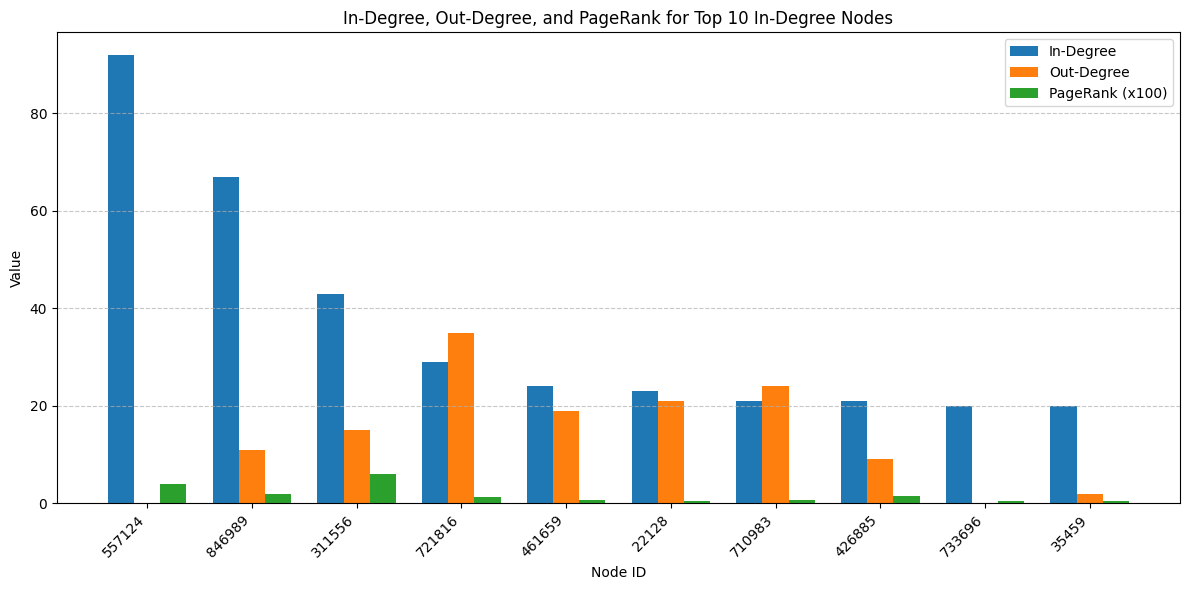

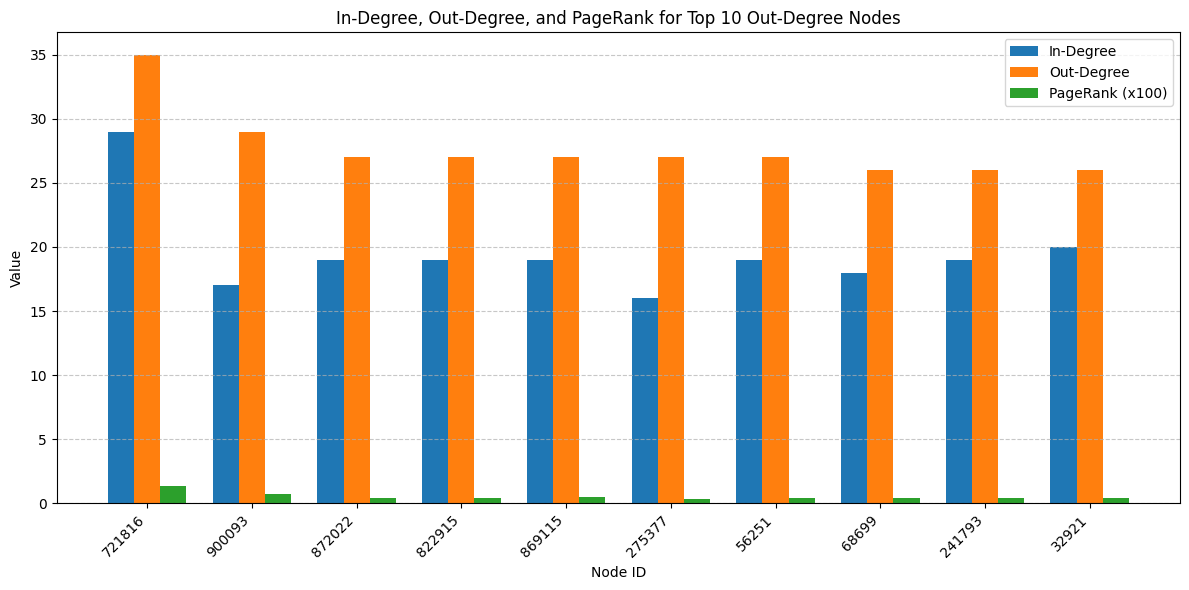

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Convert to DataFrame for easier plotting
df_top_in_degree = pd.DataFrame(top_in_degree_data)
df_top_out_degree = pd.DataFrame(top_out_degree_data)

# Set up plot for top 10 in-degree nodes
fig, ax = plt.subplots(figsize=(12, 6))

bar_width = 0.25
index = np.arange(len(df_top_in_degree))

bar1 = ax.bar(index, df_top_in_degree['in_degree'], bar_width, label='In-Degree')
bar2 = ax.bar(index + bar_width, df_top_in_degree['out_degree'], bar_width, label='Out-Degree')
bar3 = ax.bar(index + 2 * bar_width, df_top_in_degree['pagerank'] * 100, bar_width, label='PageRank (x100)') # Scale PageRank for visibility

ax.set_xlabel('Node ID')
ax.set_ylabel('Value')
ax.set_title('In-Degree, Out-Degree, and PageRank for Top 10 In-Degree Nodes')
ax.set_xticks(index + bar_width)
ax.set_xticklabels(df_top_in_degree['node'], rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Set up plot for top 10 out-degree nodes
fig, ax = plt.subplots(figsize=(12, 6))

bar1 = ax.bar(index, df_top_out_degree['in_degree'], bar_width, label='In-Degree')
bar2 = ax.bar(index + bar_width, df_top_out_degree['out_degree'], bar_width, label='Out-Degree')
bar3 = ax.bar(index + 2 * bar_width, df_top_out_degree['pagerank'] * 100, bar_width, label='PageRank (x100)') # Scale PageRank for visibility

ax.set_xlabel('Node ID')
ax.set_ylabel('Value')
ax.set_title('In-Degree, Out-Degree, and PageRank for Top 10 Out-Degree Nodes')
ax.set_xticks(index + bar_width)
ax.set_xticklabels(df_top_out_degree['node'], rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


From the above barplot, it can be observed that in-links are a stronger indicator of PageRank centrality than out-links.

In [91]:
sorted_pagerank = sorted(pagerank_centrality.items(), key=lambda item: item[1], reverse=True)
top_5_pagerank_nodes = [node for node, score in sorted_pagerank[:5]]

print("Top 5 nodes by PageRank centrality:")
for node in top_5_pagerank_nodes:
  print(f"Node {node}: PageRank = {pagerank_centrality[node]:.4f}")

Top 5 nodes by PageRank centrality:
Node 311556: PageRank = 0.0602
Node 557124: PageRank = 0.0404
Node 568687: PageRank = 0.0316
Node 48561: PageRank = 0.0282
Node 846989: PageRank = 0.0197


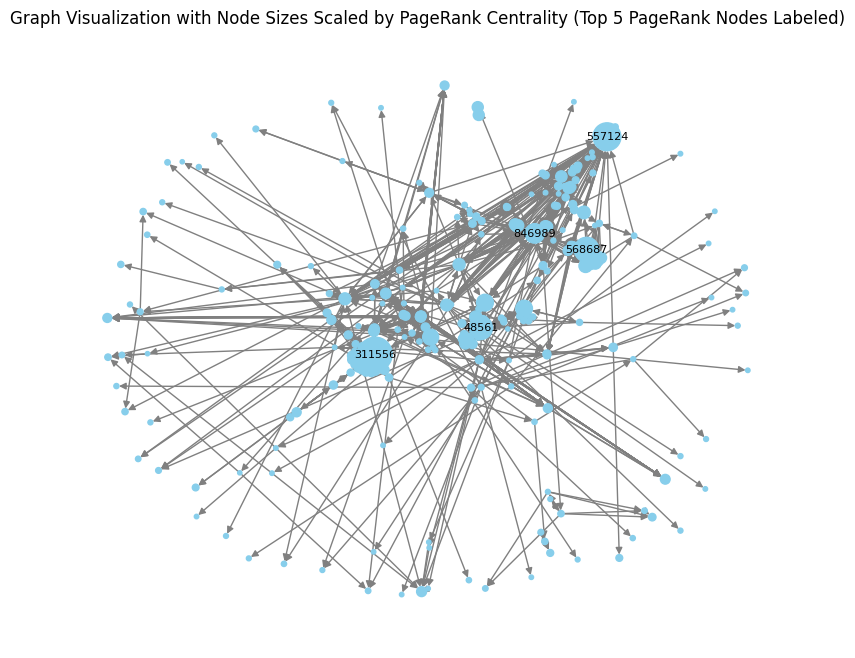

In [92]:
node_sizes = [v * 10000 for v in pagerank_centrality.values()]

# Create a dictionary for labels
node_labels = {}
for node in G.nodes():
  if node in top_5_pagerank_nodes:
    node_labels[node] = str(node) # Convert node ID to string for label
  else:
    node_labels[node] = '' # Unlabeled nodes

pos = nx.spring_layout(G)

plt.figure(figsize=(10, 8))
nx.draw_networkx(G, pos, node_size=node_sizes, with_labels=True, labels=node_labels, edge_color='gray', node_color='skyblue', font_size=8)
plt.title('Graph Visualization with Node Sizes Scaled by PageRank Centrality (Top 5 PageRank Nodes Labeled)')
plt.axis('off')
plt.show()

Graphs are usually unique, so many don't agree with different metrics. For this example PageRank was probably most correct as the dataset was Google Web Graph but it all depends on context.